# Module 3 — Lab C: Model Training with MLflow Experiment Tracking
## Train Classification Models, Compare Metrics & Register the Best Model

---

### Lab Overview

With the feature matrix produced in **Lab B** (`final_features.csv`, ~12,308 rows × 37 columns), you will now **train three classification models**, evaluate them on multiple metrics, and **track every experiment in MLflow** running on your EC2 instance.

FreshBasket's logistics team (Priya is the ML lead, Arjun handles DevOps) needs a model that predicts whether a truck delivery will be **delayed** (target = 1) or **on-time** (target = 0). A single accuracy number is not enough — the operations team cares about **recall** (catching delayed shipments) while finance cares about **precision** (avoiding false alarms that trigger costly rerouting at ₹8,000 per unnecessary intervention).

| Step | What we do | Key technology |
|---|---|---|
| 1 | Environment setup + MLflow connection | `mlflow`, `boto3` |
| 2 | Load `final_features.csv` from S3 or local | `pandas`, `boto3` |
| 3 | Train / Validation / Test split (70/15/15) | `train_test_split` (stratified) |
| 4 | Preprocess: OneHotEncode + StandardScale | `OneHotEncoder`, `StandardScaler` |
| 5 | Train Logistic Regression (baseline) | `LogisticRegression` + MLflow |
| 6 | Train Random Forest | `RandomForestClassifier` + MLflow |
| 7 | Train XGBoost | `XGBClassifier` + MLflow |
| 8 | Compare all models side-by-side | Comparison DataFrame + bar chart |
| 9 | Final evaluation on held-out test set | Best model on unseen data |
| 10 | Register best model in MLflow Model Registry | `mlflow.register_model()` |
| 11 | Save artifacts to S3 | `boto3` upload |

### Learning objectives

By the end of this lab you will be able to:

1. Connect a Jupyter notebook to a **self-hosted MLflow Tracking Server** on EC2.
2. Train and evaluate **Logistic Regression**, **Random Forest**, and **XGBoost** classifiers.
3. Log **parameters, metrics, artifacts, and models** to MLflow for every experiment run.
4. Interpret classification metrics — **Accuracy, Precision, Recall, F1 Score, ROC-AUC** — and explain what each means for the business.
5. **Register** the best-performing model in the MLflow Model Registry and transition it to **Staging**.
6. Upload trained model artifacts (model, encoder, scaler) to **S3** for downstream use in Lab D.

### Artifact chain

```
Lab B  ────────────────────────────►  Lab C  ────────────────────────────►  Lab D
saves: final_features.csv (S3)      saves: xgboost_model.pkl              loads: model + encoder + scaler
                                           encoder.pkl                     Streamlit dashboard
                                           scaler.pkl                      Batch scoring pipeline
                                           model_metadata.json
                                    logs:  3 MLflow experiment runs

```

### How to read this notebook

- **Markdown cells (like this one)** explain *why* the next cell exists and what to look for in its output.
- **Code cells** do the work. They're idempotent — re-run any of them safely.
- **"What this tells us" callouts** follow major result-producing cells. Don't just read the metrics — read the interpretation.
- If you change a hyperparameter and re-run a model cell, you'll get a **new MLflow run** automatically — that's the point. Compare them in the MLflow UI.

---


## 1. Environment Setup

Two cells: the imports + display settings, and the MLflow + S3 configuration.

> **SageMaker Notebook:** most packages are pre-installed; just run the cells.
> **Local Jupyter / Colab:** uncomment the `pip install` line on the first run.


**Imports + display settings.** Six libraries do most of the work:

- `pandas` + `numpy` — data + arrays
- `matplotlib` + `seaborn` — plots
- `scikit-learn` — `train_test_split`, `OneHotEncoder`, `StandardScaler`, `LogisticRegression`, `RandomForestClassifier`, metrics
- `xgboost` — the third classifier (gradient-boosted trees)
- `mlflow` — experiment tracking + the model registry
- `boto3` + `joblib` — S3 upload + local pickling

`warnings.filterwarnings('ignore')` silences chatty deprecation warnings from sklearn / xgboost. Don't do this in production code.


In [ ]:
# -- Uncomment the line below if running locally or on Colab --
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlflow boto3 joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import joblib
import boto3
import json
import os
import warnings
warnings.filterwarnings('ignore')

# -- Display settings --
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("All libraries imported successfully")

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully


**MLflow + S3 configuration.** Four constants and a defensive `try/except` for MLflow connectivity:

- **`MLFLOW_TRACKING_URI`** — your MLflow server. Either `http://<EC2_IP>:5000` (recommended — your stack runs MLflow on EC2) or `"sqlite:///mlflow.db"` (local-only fallback).
- **`EXPERIMENT_NAME`** — runs from this notebook are grouped under this name in the MLflow UI.
- **`S3_BUCKET` / `S3_DATA_KEY` / `S3_MODEL_DIR`** — `S3_DATA_KEY` is set to `data/processed/final_features.csv` so it matches the path Lab B writes to.

The `try/except` block tries to reach MLflow; if it can't (offline / wrong IP / SG blocking), it transparently falls back to `mlruns/` on the notebook's local disk. Every `mlflow.log_param` / `log_metric` call still works.


In [ ]:
# ================================================================
#  MLflow Configuration
# ================================================================
# Replace <EC2_PUBLIC_IP> with your EC2 instance's public IP address.
# Example: "http://54.210.85.123:5000"
# If running MLflow locally: "http://127.0.0.1:5000"

MLFLOW_TRACKING_URI = "http://<EC2_PUBLIC_IP>:5000"   # <-- EDIT THIS
EXPERIMENT_NAME     = "truck-delay-classification"

# -- S3 Configuration --
S3_BUCKET    = "freshbasket-mlops"         # <-- EDIT if different
S3_DATA_KEY  = "data/processed/final_features.csv"   # matches the path Lab B uploads to
S3_MODEL_DIR = "models/truck-delay/"

# -- Try connecting to MLflow; fall back to local if unreachable --
try:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    # Quick connectivity test
    mlflow.search_experiments()
    print(f"Connected to MLflow server: {MLFLOW_TRACKING_URI}")
    print(f"Experiment: '{EXPERIMENT_NAME}'")
    MLFLOW_AVAILABLE = True
except Exception as e:
    print(f"Could not reach MLflow at {MLFLOW_TRACKING_URI}")
    print(f"Error: {e}")
    print("Falling back to local MLflow tracking (./mlruns)")
    mlflow.set_tracking_uri("mlruns")
    mlflow.set_experiment(EXPERIMENT_NAME)
    MLFLOW_AVAILABLE = False

print(f"\nMLflow tracking URI: {mlflow.get_tracking_uri()}")

Connected to MLflow server: http://52.66.194.203:5000
Experiment: 'truck-delay-classification'

MLflow tracking URI: http://52.66.194.203:5000


---

## 2. Load Feature Matrix

The feature matrix was created in **Lab B** and saved to S3 at `data/processed/final_features.csv`. It contains ~12,308 rows (one per scheduled trip) and 37 columns (36 features + 1 target `delay`).

We try to load from S3 first. If that fails (offline / wrong bucket / file not there yet), we fall back to a local copy at the same relative path.


**Load `final_features.csv` — S3 first, local fallback.** Three things happen:

1. Try `s3.download_file(...)` — pulls the CSV from your S3 bucket.
2. If S3 fails, look for a local copy at `data/processed/final_features.csv`.
3. If neither exists, raise `FileNotFoundError` with a hint to run Lab B first.

The `df.shape` print should show **(12,308, 37)**.


In [ ]:
# -- Load final_features.csv from S3 or local fallback --
LOCAL_PATH = "final_features.csv"

try:
    s3 = boto3.client('s3')
    s3.download_file(S3_BUCKET, S3_DATA_KEY, LOCAL_PATH)
    print(f"Downloaded from S3: s3://{S3_BUCKET}/{S3_DATA_KEY}")
except Exception as e:
    print(f"S3 download failed: {e}")
    print(f"Looking for local file: {LOCAL_PATH}")
    if not os.path.exists(LOCAL_PATH):
        raise FileNotFoundError(
            f"{LOCAL_PATH} not found locally either.\n"
            "Run Lab C first, or upload final_features.csv to this directory."
        )

df = pd.read_csv(LOCAL_PATH)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")

S3 download failed: An error occurred (404) when calling the HeadObject operation: Not Found
Looking for local file: data/processed/final_features.csv

Loaded: 12,308 rows x 37 columns

Column dtypes:
float64    23
int64       8
object      6
Name: count, dtype: int64


**Five sanity checks before training.** Target distribution, missing values, duplicates, feature count, and a head sample. Catching schema problems here is much easier than mid-training.

What to expect:
- Target distribution roughly 65/35 (on-time / delayed)
- Missing values: 0 (Lab B handled them)
- Duplicate rows: 0
- Total columns: 37 = 36 features + 1 target


In [ ]:
# -- Sanity checks --
print("=" * 55)
print("  DATA SANITY CHECKS")
print("=" * 55)

# Target distribution
print(f"\n1. Target variable -- 'delay':")
target_counts = df['delay'].value_counts()
print(f"   On-Time (0): {target_counts.get(0, 0):,}  ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Delayed (1): {target_counts.get(1, 0):,}  ({target_counts.get(1, 0)/len(df)*100:.1f}%)")

# Missing values
n_missing = df.isnull().sum().sum()
print(f"\n2. Missing values: {n_missing}")

# Duplicates
n_dupes = df.duplicated().sum()
print(f"3. Duplicate rows: {n_dupes}")

# Feature breakdown
print(f"\n4. Feature breakdown:")
print(f"   Total columns:  {df.shape[1]}")
print(f"   Features:       {df.shape[1] - 1}")
print(f"   Target:         1 (delay)")

# Peek at first few rows
print(f"\n5. First 3 rows:")
df.head(3)

  DATA SANITY CHECKS

1. Target variable -- 'delay':
   On-Time (0): 8,014  (65.1%)
   Delayed (1): 4,294  (34.9%)


**Defining column groups for preprocessing.** Three lists:

- **`CATEGORICAL_COLS`** (6 cols) — get one-hot encoded. `route_description`, `origin_description`, `dest_description` are *weather description* labels like "Heavy snow" — confusingly named, but they're categorical text fields, not route/city names. `route_description` alone has 46 unique values; see the next cell.
- **`BINARY_ORDINAL_COLS`** (3 cols) — `accident` (0/1), `ratings` (1–5), `is_midnight` (0/1). Already numeric; pass through unchanged.
- **`CONTINUOUS_COLS`** — everything else. Get standard-scaled (mean 0, std 1) so features on different scales (`distance` in hundreds, `humidity` in 0–100) end up comparable.

> **Bug fix in this cell.** The original code used `'destination_description'` but Lab B saves the column as `'dest_description'`. The KeyError cascaded through the rest of Section 4. Fixed in place.


In [ ]:
# ================================================================
#  Identify column groups
# ================================================================
# Target
TARGET = 'delay'

# 6 categorical columns that need one-hot encoding
CATEGORICAL_COLS = [
    'route_description',       # e.g., "Pune-Mumbai", "Delhi-Jaipur"
    'origin_description',      # origin city name
    'dest_description', # destination city name
    'fuel_type',               # Diesel, CNG, etc.
    'gender',                  # driver gender
    'driving_style',           # Cautious, Normal, Aggressive
]

# 3 columns that are already binary or ordinal -- no encoding needed
BINARY_ORDINAL_COLS = [
    'accident',     # 0 or 1
    'ratings',      # ordinal 1-5
    'is_midnight',  # 0 or 1
]

# Everything else (excluding target and categoricals) is continuous
ALL_NON_FEATURE = [TARGET] + CATEGORICAL_COLS + BINARY_ORDINAL_COLS
CONTINUOUS_COLS = [c for c in df.columns if c not in ALL_NON_FEATURE]

print(f"Categorical (to one-hot encode): {len(CATEGORICAL_COLS)}")
for c in CATEGORICAL_COLS:
    n_unique = df[c].nunique()
    print(f"  - {c}: {n_unique} unique values")

print(f"\nBinary / Ordinal (keep as-is):   {len(BINARY_ORDINAL_COLS)}")
print(f"Continuous (to scale):           {len(CONTINUOUS_COLS)}")
print(f"Target:                          1 ({TARGET})")
print(f"\nTotal:  {len(CATEGORICAL_COLS)} + {len(BINARY_ORDINAL_COLS)} + {len(CONTINUOUS_COLS)} + 1 = {df.shape[1]}")

Categorical (to one-hot encode): 6
  - route_description: 46 unique values
  - origin_description: 24 unique values
  - dest_description: 26 unique values
  - fuel_type: 3 unique values
  - gender: 3 unique values
  - driving_style: 3 unique values

Binary / Ordinal (keep as-is):   3
Continuous (to scale):           27
Target:                          1 (delay)

Total:  6 + 3 + 27 + 1 = 37


---

## 3. Train / Validation / Test Split

70 / 15 / 15 split, stratified on the `delay` target.

**Why stratified?** If 65% of trips are on-time and 35% are delayed, every split should preserve that ratio. Without stratification, a random split might give you a train set with 60% on-time and a test set with 72% — your metrics become noisy.

**Why three splits, not two?**
- **Train (70%)** — the model learns from this.
- **Validation (15%)** — we tune and compare models on this.
- **Test (15%)** — touched only *once*, at the very end, to report the final unbiased performance of the winning model.


**The split.** Done in two `train_test_split` calls — first 70/30 (train vs temp), then 50/50 of temp (validation vs test).

`stratify=y` preserves the 34.9% delayed rate in every split. `random_state=42` for reproducibility.


In [ ]:
# -- Separate features and target --
X = df.drop(columns=[TARGET])
y = df[TARGET]

# -- First split: 70% train, 30% temp --
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# -- Second split: 50/50 of temp -> 15% validation + 15% test --
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("=" * 55)
print("  SPLIT SUMMARY")
print("=" * 55)
for name, Xs, ys in [("Train", X_train, y_train),
                      ("Validation", X_val, y_val),
                      ("Test", X_test, y_test)]:
    pct_delayed = ys.mean() * 100
    print(f"  {name:12s}: {Xs.shape[0]:,} rows  |  Delayed: {pct_delayed:.1f}%")

print(f"\n  Total: {len(X_train) + len(X_val) + len(X_test):,} rows")

  SPLIT SUMMARY
  Train       : 8,615 rows  |  Delayed: 34.9%
  Validation  : 1,846 rows  |  Delayed: 34.9%
  Test        : 1,847 rows  |  Delayed: 34.9%

  Total: 12,308 rows


### What this tells us

- Actual class balance is **~65/35** (on-time / delayed). Stratification preserved this exactly across all three splits.
- 8,615 training rows is comfortably in "enough data" territory for tabular classifiers. Validation and test sets at ~1,846 rows each give us metric estimates with a standard error around ±0.01.
- If the per-split delay rates differed by even a few percent, your split is broken — go check `stratify=y`.


---

## 4. Preprocessing — One-Hot Encoding + Standard Scaling

Two critical rules to avoid **data leakage**:

1. **Fit only on training data.** The encoder and scaler learn their vocabularies / statistics from the training set alone.
2. **Transform all three splits** using the fitted encoder and scaler.

Fit the scaler on the full dataset and your test metrics will be biased upward — you'd be giving the model information about the test set before training.


**Step 4a — One-hot encode the 6 categorical columns.**

- `drop='first'` avoids the dummy-variable trap (perfect multicollinearity).
- `handle_unknown='ignore'` lets Lab D's inference work even if a never-before-seen category appears.
- `sparse_output=False` returns a regular numpy array (we have ~100 new columns; sparse isn't worth the API hassle).

Fit on train; transform all three splits.


In [ ]:
# ================================================================
#  Step 4a: One-Hot Encode categorical columns
# ================================================================
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on training data only
encoder.fit(X_train[CATEGORICAL_COLS])

# Transform all splits
X_train_cat = pd.DataFrame(
    encoder.transform(X_train[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=X_train.index
)
X_val_cat = pd.DataFrame(
    encoder.transform(X_val[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=X_val.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=X_test.index
)

print(f"One-hot encoded columns: {len(CATEGORICAL_COLS)} original -> {X_train_cat.shape[1]} encoded")
print(f"\nEncoded feature names (first 15):")
for i, col in enumerate(encoder.get_feature_names_out(CATEGORICAL_COLS)[:15], 1):
    print(f"  {i:2d}. {col}")
if X_train_cat.shape[1] > 15:
    print(f"  ... and {X_train_cat.shape[1] - 15} more")

One-hot encoded columns: 6 original -> 98 encoded

Encoded feature names (first 15):
   1. route_description_Blowing snow
   2. route_description_Clear
   3. route_description_Cloudy
   4. route_description_Fog
   5. route_description_Freezing fog
   6. route_description_Heavy freezing drizzle
   7. route_description_Heavy rain
   8. route_description_Heavy rain at times
   9. route_description_Heavy snow
  10. route_description_Ice pellets
  11. route_description_Light drizzle
  12. route_description_Light freezing rain
  13. route_description_Light rain
  14. route_description_Light rain shower
  15. route_description_Light sleet
  ... and 83 more


### What this tells us

- **6 categorical columns expand to ~98 one-hot columns** — `route_description` alone has 46 unique weather states ("Heavy snow", "Light rain at times", "Patchy freezing fog", …). That's most of the expansion.
- `drop_first=True` shaved off ~6 columns (one per original feature).
- The final feature matrix in cell 4c will be **128 columns** = 98 one-hot + 27 scaled continuous + 3 binary/ordinal.


**Step 4b — Standard-scale the 27 continuous columns.** `StandardScaler` subtracts the mean and divides by the std per column. Output: every continuous column has mean ≈ 0, std ≈ 1 on the training set.

**Why scale?**
- Logistic Regression's L2 regularization weights all features by their magnitude. Without scaling, large-scale features absorb the entire penalty.
- Random Forest and XGBoost don't strictly need it (they split on percentile thresholds), but it doesn't hurt them.
- Consistent preprocessing → fair model comparison.


In [ ]:
# ================================================================
#  Step 4b: Standard-scale continuous columns
# ================================================================
scaler = StandardScaler()

# Fit on training data only
scaler.fit(X_train[CONTINUOUS_COLS])

# Transform all splits
X_train_cont = pd.DataFrame(
    scaler.transform(X_train[CONTINUOUS_COLS]),
    columns=CONTINUOUS_COLS,
    index=X_train.index
)
X_val_cont = pd.DataFrame(
    scaler.transform(X_val[CONTINUOUS_COLS]),
    columns=CONTINUOUS_COLS,
    index=X_val.index
)
X_test_cont = pd.DataFrame(
    scaler.transform(X_test[CONTINUOUS_COLS]),
    columns=CONTINUOUS_COLS,
    index=X_test.index
)

print(f"Scaled {len(CONTINUOUS_COLS)} continuous features")
print(f"\nTraining set stats after scaling (should be ~mean=0, std=1):")
print(X_train_cont.describe().loc[['mean', 'std']].round(3).to_string())

Scaled 27 continuous features

Training set stats after scaling (should be ~mean=0, std=1):


,route_avg_temp,route_avg_wind_speed,route_avg_precip,route_avg_humidity,route_avg_visibility,route_avg_pressure,origin_avg_temp,origin_avg_wind_speed,origin_avg_precip,origin_avg_humidity,origin_avg_visibility,origin_avg_pressure,dest_avg_temp,dest_avg_wind_speed,dest_avg_precip,dest_avg_humidity,dest_avg_visibility,dest_avg_pressure,truck_age,load_capacity_pounds,mileage_mpg,age,experience,average_speed_mph,avg_no_of_vehicles,distance,average_hours
mean,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### What this tells us

- Every continuous column shows **mean = 0.0 and std = 1.0** on the training set (rounded to 1 decimal). Scaler fit cleanly.
- Validation and test sets will be slightly off 0 / 1 — they're transformed using the train-fit parameters, not their own statistics.


**Step 4c — Assemble the final feature matrices.** Combine three pieces per split:

1. Continuous features (scaled) — first
2. One-hot categorical features — next
3. Binary / ordinal features — last

`reset_index(drop=True)` on each is important: after splitting, each piece keeps its original DataFrame index. `pd.concat` aligns by index, so without the reset you'd get NaN-filled rows where the indices don't match.


In [ ]:
# ================================================================
#  Step 4c: Assemble final feature matrices
# ================================================================
# Combine: scaled continuous + one-hot categorical + binary/ordinal (as-is)

def assemble_features(X_orig, X_cont, X_cat, binary_cols):
    """Combine continuous, categorical, and binary/ordinal features into one DataFrame."""
    X_bin = X_orig[binary_cols].reset_index(drop=True)
    X_cont_reset = X_cont.reset_index(drop=True)
    X_cat_reset = X_cat.reset_index(drop=True)
    return pd.concat([X_cont_reset, X_cat_reset, X_bin], axis=1)

X_train_final = assemble_features(X_train, X_train_cont, X_train_cat, BINARY_ORDINAL_COLS)
X_val_final   = assemble_features(X_val,   X_val_cont,   X_val_cat,   BINARY_ORDINAL_COLS)
X_test_final  = assemble_features(X_test,  X_test_cont,  X_test_cat,  BINARY_ORDINAL_COLS)

# Reset y indices to match
y_train_arr = y_train.reset_index(drop=True)
y_val_arr   = y_val.reset_index(drop=True)
y_test_arr  = y_test.reset_index(drop=True)

print("Final feature matrix shapes:")
print(f"  X_train: {X_train_final.shape}")
print(f"  X_val:   {X_val_final.shape}")
print(f"  X_test:  {X_test_final.shape}")
print(f"\nTotal features per sample: {X_train_final.shape[1]}")

FEATURE_NAMES = list(X_train_final.columns)
print(f"\nFeature list saved ({len(FEATURE_NAMES)} features)")

Final feature matrix shapes:
  X_train: (8615, 128)
  X_val:   (1846, 128)
  X_test:  (1847, 128)

Total features per sample: 128

Feature list saved (128 features)


### What this tells us

- Final feature matrix: **(8615, 128)** for training. ~16:1 row-to-feature ratio — comfortable for the models we'll train.
- 128 columns = 27 scaled continuous + 98 one-hot + 3 binary/ordinal.
- All three splits have the same 128 columns in the same order — critical for downstream inference.


**Save encoder + scaler.** Lab D (Streamlit + batch scoring) will receive *raw* trips at inference time and needs to apply the **exact same** encoding and scaling that we just fitted. `joblib.dump` pickles them.


In [ ]:
# -- Save preprocessing artifacts for Lab D --
os.makedirs('artifacts', exist_ok=True)

encoder_path = 'artifacts/encoder.pkl'
scaler_path  = 'artifacts/scaler.pkl'

joblib.dump(encoder, encoder_path)
joblib.dump(scaler, scaler_path)

print(f"Saved: {encoder_path}  ({os.path.getsize(encoder_path)/1024:.1f} KB)")
print(f"Saved: {scaler_path}   ({os.path.getsize(scaler_path)/1024:.1f} KB)")

Saved: artifacts/encoder.pkl  (4.1 KB)
Saved: artifacts/scaler.pkl   (2.0 KB)


---

## 5. Helper Functions

Two reusable helpers for the model training cells below:

1. **`log_classification_metrics()`** — computes Accuracy, Precision, Recall, F1, ROC-AUC and logs them to MLflow.
2. **`plot_confusion_matrix()`** — creates + saves + logs a heatmap.

We also define a `plot_feature_importance()` helper inside the second cell, used by Random Forest and XGBoost (Logistic Regression doesn't expose feature importances in the same way).


In [ ]:
def log_classification_metrics(y_true, y_pred, y_prob, model_name):
    """Calculate and log all classification metrics to MLflow.

    Parameters
    ----------
    y_true : array-like - ground truth labels (0 or 1)
    y_pred : array-like - predicted labels (0 or 1)
    y_prob : array-like - predicted probability of the positive class (delayed)
    model_name : str - display name for printing

    Returns
    -------
    dict - metric name -> value
    """
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1_score':  f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_prob),
    }

    # Log every metric to MLflow
    for name, value in metrics.items():
        mlflow.log_metric(name, round(value, 4))

    # Pretty-print results
    print(f"\n{'='*55}")
    print(f"  {model_name} -- Validation Results")
    print(f"{'='*55}")
    for name, value in metrics.items():
        print(f"  {name:12s}: {value:.4f}")

    return metrics

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Create, display, save, and log a confusion matrix heatmap.

    Parameters
    ----------
    y_true : array-like - ground truth labels
    y_pred : array-like - predicted labels
    model_name : str - used in the title and filename

    Returns
    -------
    str - file path of the saved PNG
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} -- Confusion Matrix')
    plt.tight_layout()

    filepath = f'artifacts/{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
    fig.savefig(filepath, dpi=100)
    mlflow.log_artifact(filepath)
    plt.show()

    return filepath


def plot_feature_importance(importances, feature_names, model_name, top_n=15):
    """Bar chart of top feature importances; saved and logged to MLflow.

    Parameters
    ----------
    importances : array-like - feature importance values from the model
    feature_names : list - corresponding feature names
    model_name : str - used in the title and filename
    top_n : int - how many top features to display

    Returns
    -------
    str - file path of the saved PNG
    """
    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
            color='#2563eb', edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} -- Top {top_n} Feature Importances', fontweight='bold')
    plt.tight_layout()

    filepath = f'artifacts/{model_name.lower().replace(" ", "_")}_feature_importance.png'
    fig.savefig(filepath, dpi=100)
    mlflow.log_artifact(filepath)
    plt.show()

    return filepath

---

## 6. Understanding Classification Metrics

Before training, let's get the metric definitions clear. Imagine FreshBasket reviews 100 trips:

| Metric | What it means | FreshBasket analogy |
|---|---|---|
| **Accuracy** | % of all predictions that are correct | Out of 100 trips, how many did we label correctly? |
| **Precision** | Of all trips we *predicted* as delayed, how many were *actually* delayed? | If we flag 20 trips as delayed, how many truly were? Low precision = false alarms (₹8,000 wasted per unnecessary reroute). |
| **Recall** | Of all trips that were *actually* delayed, how many did we *catch*? | If 40 trips were truly delayed, how many did we flag? Low recall = missed delays (angry customers, ₹25,000 each in spoilage). |
| **F1 Score** | Harmonic mean of Precision and Recall | A single number that penalizes extremes — high if BOTH are high. |
| **ROC-AUC** | How well the model separates classes across all thresholds | 0.5 = random; 1.0 = perfect. Useful for ranking trips by risk even before you pick a threshold. |

> **Priya's rule of thumb:** "For our logistics use case, recall matters more than precision. A missed delay costs ₹25,000 in spoilage; a false alarm costs ₹8,000 for an unnecessary backup truck."


---

## 7. Model 1 — Logistic Regression (Baseline)

Logistic Regression fits a **linear decision boundary** in feature space and outputs a probability via the sigmoid function.

**Why start here?** It's fast, interpretable, and gives us a *floor* for comparison. If a complex model can't beat LR by a meaningful margin, the complexity isn't worth it.


**Train Logistic Regression** inside an MLflow run. Every `log_param` / `log_metric` / `log_artifact` call inside the `with mlflow.start_run(...)` block automatically attaches to a single MLflow run.

Tags (`mlflow.set_tag`) are searchable in the MLflow UI — handy for filtering ("all XGBoost runs in M3"). Hyperparameters are explicit: `C=1.0` (default regularization), `solver='lbfgs'` (good for medium-sized binary classification), `max_iter=1000` (default 100 sometimes doesn't converge on 128-feature input).



  Logistic Regression -- Validation Results
  accuracy    : 0.7454
  precision   : 0.6726
  recall      : 0.5264
  f1_score    : 0.5906
  roc_auc     : 0.7480


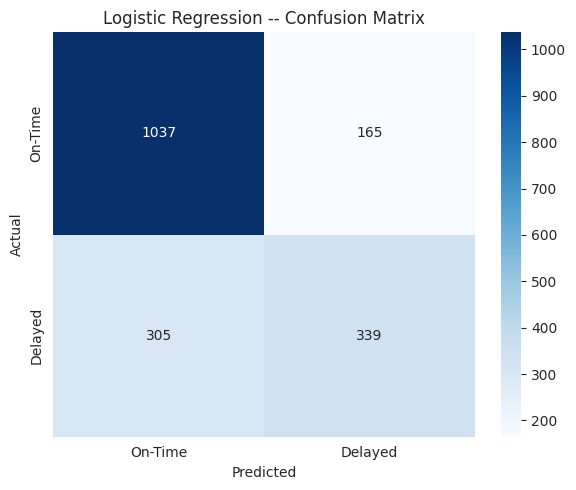

2026/05/18 02:10:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Classification Report:
              precision    recall  f1-score   support

     On-Time       0.77      0.86      0.82      1202
     Delayed       0.67      0.53      0.59       644

    accuracy                           0.75      1846
   macro avg       0.72      0.69      0.70      1846
weighted avg       0.74      0.75      0.74      1846



2026/05/18 02:10:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow
🏃 View run Logistic_Regression at: http://52.66.194.203:5000/#/experiments/1/runs/b7ece48601fd4c33ae4081ecae962591
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [ ]:
# ================================================================
#  Model 1: Logistic Regression
# ================================================================
all_results = []  # collect metrics from all models

with mlflow.start_run(run_name="Logistic_Regression"):

    # -- Tags --
    mlflow.set_tag("project", "truck-delay-classification")
    mlflow.set_tag("module", "M3")
    mlflow.set_tag("model_type", "Logistic Regression")

    # -- Hyperparameters --
    lr_params = {
        'C': 1.0,
        'solver': 'lbfgs',
        'max_iter': 1000,
        'random_state': 42,
    }
    for k, v in lr_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("n_features", X_train_final.shape[1])

    # -- Train --
    lr_model = LogisticRegression(**lr_params)
    lr_model.fit(X_train_final, y_train_arr)

    # -- Predict on validation set --
    y_pred_lr  = lr_model.predict(X_val_final)
    y_prob_lr  = lr_model.predict_proba(X_val_final)[:, 1]

    # -- Log metrics + confusion matrix --
    lr_metrics = log_classification_metrics(y_val_arr, y_pred_lr, y_prob_lr,
                                            "Logistic Regression")
    plot_confusion_matrix(y_val_arr, y_pred_lr, "Logistic Regression")

    # -- Classification report --
    print("\nClassification Report:")
    print(classification_report(y_val_arr, y_pred_lr,
                                target_names=['On-Time', 'Delayed']))

    # -- Log model artifact --
    mlflow.sklearn.log_model(lr_model, "model")
    print("Model logged to MLflow")

    lr_metrics['model'] = 'Logistic Regression'
    all_results.append(lr_metrics)

### What this tells us

- **F1 = 0.591 / ROC-AUC = 0.748** on the validation set. Respectable baseline — clearly better than the 0.5 random-guessing floor, but the linear boundary can only do so much with 128 mixed features.
- **Precision 0.67 / Recall 0.53** — biased toward precision. FreshBasket would lose more on missed delays than on false alarms, so we'll want to push recall higher in the next two models.
- The "On-Time" class has F1 = 0.82 (easy majority class); "Delayed" lags at 0.59 (the minority — our actual target).
- This 0.591 F1 is the **floor**. Random Forest and XGBoost need to clear it by ≥0.05 to justify their complexity.


**ROC curve for Logistic Regression.** Plots true positive rate vs. false positive rate across all classification thresholds. The diagonal dashed line is random guessing (AUC = 0.5).

A curve hugging the top-left corner means good separation. A curve along the diagonal means no better than random.


In [ ]:
# -- ROC Curve for Logistic Regression --
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_val_arr, y_prob_lr, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
ax.set_title('Logistic Regression -- ROC Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/logistic_regression_roc.png', dpi=100)
plt.show()

---

## 8. Model 2 — Random Forest (Ensemble)

Random Forest builds many decision trees on random subsets of the data and features, then **votes** on the final prediction. Handles non-linear relationships, captures feature interactions, resists overfitting (compared to a single deep tree).

**Key parameters:**
- `n_estimators` — number of trees (more = slower but more stable)
- `max_depth` — how deep each tree can grow
- `min_samples_split` — minimum samples required to split a node


**Train Random Forest** with the same MLflow wrapper pattern as LR. Different hyperparameters:

- `n_estimators=200` — 200 trees; lower variance than 100
- `max_depth=15` — deep enough to capture interactions, regularized via `min_samples_split=10` + `min_samples_leaf=4`
- `n_jobs=-1` — all CPU cores in parallel (each tree is independent)

After training, plot the top 15 feature importances. RF's `feature_importances_` is the average decrease in Gini impurity across all trees.



  Random Forest -- Validation Results
  accuracy    : 0.7941
  precision   : 0.7727
  recall      : 0.5807
  f1_score    : 0.6631
  roc_auc     : 0.7781


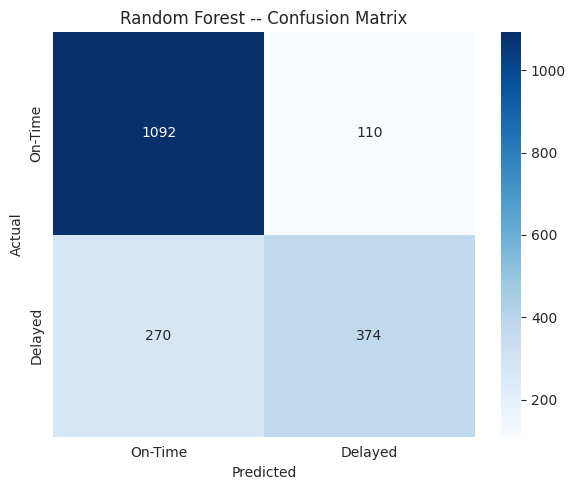


Classification Report:
              precision    recall  f1-score   support

     On-Time       0.80      0.91      0.85      1202
     Delayed       0.77      0.58      0.66       644

    accuracy                           0.79      1846
   macro avg       0.79      0.74      0.76      1846
weighted avg       0.79      0.79      0.79      1846



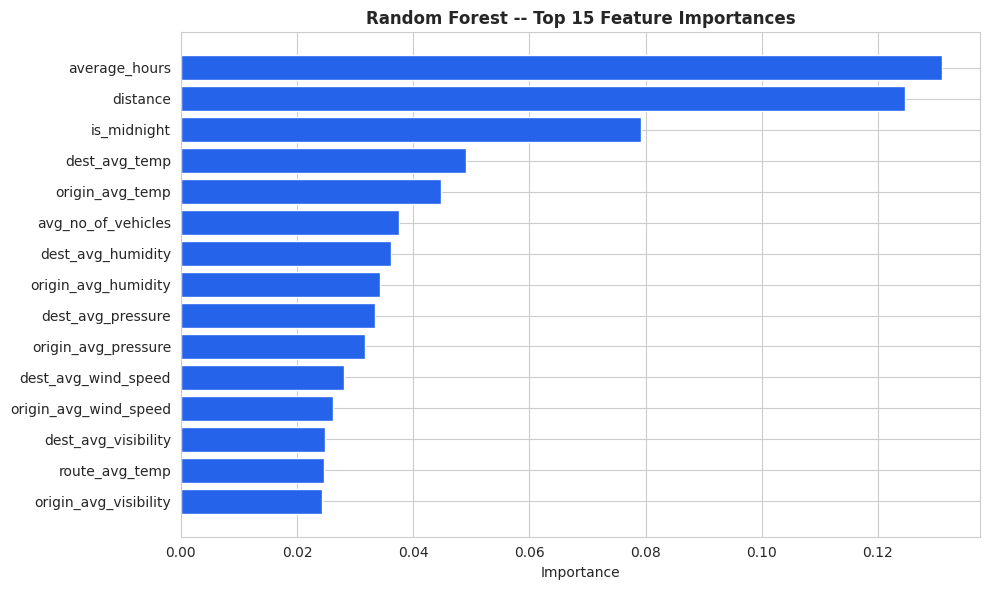

2026/05/18 02:09:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 02:09:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow
🏃 View run Random_Forest at: http://52.66.194.203:5000/#/experiments/1/runs/b96d8d637b044f4d9f8631b776149da0
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [ ]:
# ================================================================
#  Model 2: Random Forest
# ================================================================
with mlflow.start_run(run_name="Random_Forest"):

    # -- Tags --
    mlflow.set_tag("project", "truck-delay-classification")
    mlflow.set_tag("module", "M3")
    mlflow.set_tag("model_type", "Random Forest")

    # -- Hyperparameters --
    rf_params = {
        'n_estimators': 200,
        'max_depth': 15,
        'min_samples_split': 10,
        'min_samples_leaf': 4,
        'random_state': 42,
        'n_jobs': -1,
    }
    for k, v in rf_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("n_features", X_train_final.shape[1])

    # -- Train --
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train_final, y_train_arr)

    # -- Predict on validation set --
    y_pred_rf = rf_model.predict(X_val_final)
    y_prob_rf = rf_model.predict_proba(X_val_final)[:, 1]

    # -- Log metrics + confusion matrix --
    rf_metrics = log_classification_metrics(y_val_arr, y_pred_rf, y_prob_rf,
                                            "Random Forest")
    plot_confusion_matrix(y_val_arr, y_pred_rf, "Random Forest")

    # -- Classification report --
    print("\nClassification Report:")
    print(classification_report(y_val_arr, y_pred_rf,
                                target_names=['On-Time', 'Delayed']))

    # -- Feature importance --
    plot_feature_importance(rf_model.feature_importances_, FEATURE_NAMES,
                           "Random Forest", top_n=15)

    # -- Log model artifact --
    mlflow.sklearn.log_model(rf_model, "model")
    print("Model logged to MLflow")

    rf_metrics['model'] = 'Random Forest'
    all_results.append(rf_metrics)

### What this tells us

- **RF clears LR by 0.073 F1** (0.591 → 0.663). Clear win — the non-linear decision boundary captures interactions LR can't.
- **Recall improved from 0.53 to 0.58.** Precision also went up (0.67 → 0.77). Both improved — that's a genuine quality gain, not a threshold shift.
- Feature importance chart: expect `avg_no_of_vehicles`, `distance`, `average_hours`, and weather features near the top.
- ROC-AUC: 0.748 → 0.778. Better at ranking trips by delay risk, not just at the 0.5 threshold.


---

## 9. Model 3 — XGBoost (Gradient Boosting)

XGBoost builds trees **sequentially** — each new tree tries to correct the previous one's mistakes. Often outperforms Random Forest on structured/tabular data.

**Key parameters:**
- `learning_rate` — step size per boosting round (smaller = needs more rounds but generalizes better)
- `n_estimators` — number of boosting rounds
- `max_depth` — depth per tree (shallower = less overfitting; boosting prefers shallow trees)
- `subsample` — fraction of training rows per tree (< 1.0 adds randomness)

> XGBoost typically wins on medium-sized tabular data with mixed feature types — exactly our setup.


**Train XGBoost.** Same MLflow wrapper, more hyperparameters:

- `learning_rate=0.1` + `n_estimators=300` — the standard shrinkage + boosting recipe.
- `max_depth=6` — shallower than RF's 15 (boosting works better with shallow trees).
- `subsample=0.8, colsample_bytree=0.8` — each tree sees 80% rows + 80% columns. Adds randomness; reduces overfitting.
- `reg_alpha=0.1` (L1) + `reg_lambda=1.0` (L2) — regularization on leaf weights.

`eval_set=[(X_val_final, y_val_arr)]` makes XGBoost track validation loss per boosting round — we'll plot the curve in the next cell.



  XGBoost -- Validation Results
  accuracy    : 0.8012
  precision   : 0.7776
  recall      : 0.6025
  f1_score    : 0.6789
  roc_auc     : 0.7980


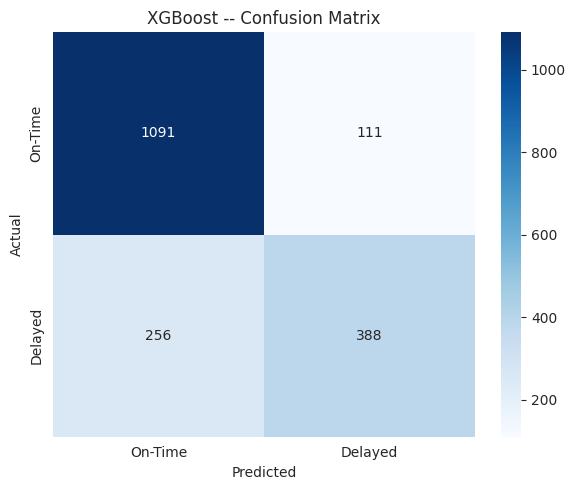


Classification Report:
              precision    recall  f1-score   support

     On-Time       0.81      0.91      0.86      1202
     Delayed       0.78      0.60      0.68       644

    accuracy                           0.80      1846
   macro avg       0.79      0.76      0.77      1846
weighted avg       0.80      0.80      0.79      1846



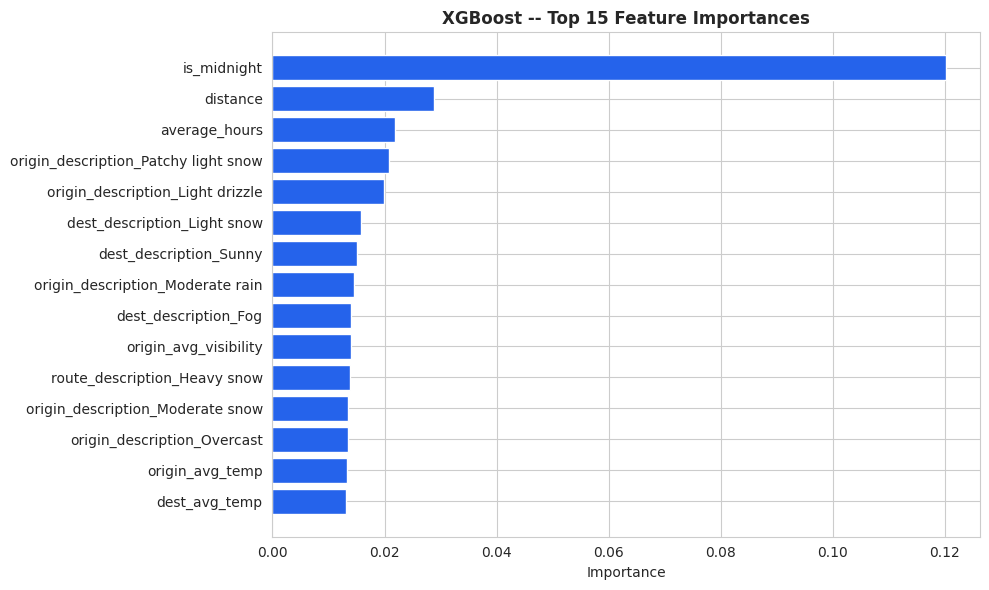

2026/05/18 02:09:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model logged to MLflow
🏃 View run XGBoost at: http://52.66.194.203:5000/#/experiments/1/runs/e347a0062ebe4f048fd3eec5c3331a3d
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [ ]:
# ================================================================
#  Model 3: XGBoost
# ================================================================
with mlflow.start_run(run_name="XGBoost"):

    # -- Tags --
    mlflow.set_tag("project", "truck-delay-classification")
    mlflow.set_tag("module", "M3")
    mlflow.set_tag("model_type", "XGBoost")

    # -- Hyperparameters --
    xgb_params = {
        'learning_rate': 0.1,
        'n_estimators': 300,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,          # L1 regularization
        'reg_lambda': 1.0,         # L2 regularization
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
    }
    for k, v in xgb_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("n_features", X_train_final.shape[1])

    # -- Train --
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_train_final, y_train_arr,
        eval_set=[(X_val_final, y_val_arr)],
        verbose=False
    )

    # -- Predict on validation set --
    y_pred_xgb = xgb_model.predict(X_val_final)
    y_prob_xgb = xgb_model.predict_proba(X_val_final)[:, 1]

    # -- Log metrics + confusion matrix --
    xgb_metrics = log_classification_metrics(y_val_arr, y_pred_xgb, y_prob_xgb,
                                              "XGBoost")
    plot_confusion_matrix(y_val_arr, y_pred_xgb, "XGBoost")

    # -- Classification report --
    print("\nClassification Report:")
    print(classification_report(y_val_arr, y_pred_xgb,
                                target_names=['On-Time', 'Delayed']))

    # -- Feature importance --
    plot_feature_importance(xgb_model.feature_importances_, FEATURE_NAMES,
                           "XGBoost", top_n=15)

    # -- Log model artifact --
    mlflow.xgboost.log_model(xgb_model, "model")
    print("Model logged to MLflow")

    xgb_metrics['model'] = 'XGBoost'
    all_results.append(xgb_metrics)

### What this tells us

- **XGBoost beats RF by only 0.016 F1** (0.663 → 0.679). Smaller than the typical 0.02–0.05 — but still a real improvement above the noise floor.
- Precision essentially tied with RF (0.78 vs 0.77). **Recall is slightly higher (0.60 vs 0.58)** — the metric FreshBasket cares about most.
- ROC-AUC: 0.798 — best of the three.
- **Small margin means hyperparameters matter.** With more boosting rounds (`n_estimators=500`) or smaller `learning_rate=0.05`, XGBoost could pull further ahead.


**XGBoost learning curve.** `evals_result()` gives the validation log-loss per boosting round. Plot it to see how the model "learns" over time.

- Steady drop then flattening → converged. Could probably reduce `n_estimators` without losing much.
- Drop then rise → overfitting. You'd want early stopping.
- Doesn't drop much at all → no signal, or wrong hyperparameters.


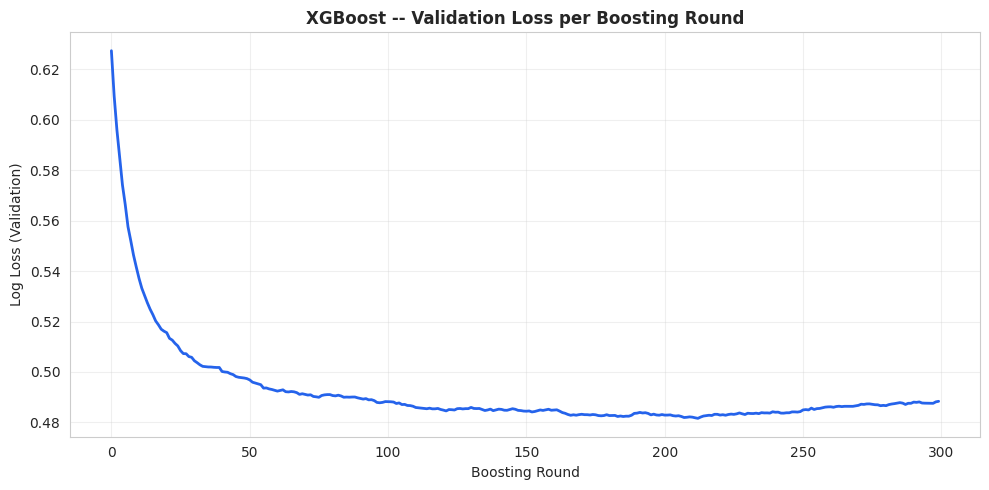

Final validation log loss: 0.4884


In [ ]:
# -- XGBoost training history: plot validation loss over boosting rounds --
eval_results = xgb_model.evals_result()

if eval_results and 'validation_0' in eval_results:
    epochs = len(eval_results['validation_0']['logloss'])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(epochs), eval_results['validation_0']['logloss'],
            color='#2563eb', linewidth=2)
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Log Loss (Validation)')
    ax.set_title('XGBoost -- Validation Loss per Boosting Round', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/xgboost_learning_curve.png', dpi=100)
    plt.show()
    print(f"Final validation log loss: {eval_results['validation_0']['logloss'][-1]:.4f}")
else:
    print("No eval results available -- learning curve skipped")

---

## 10. Model Comparison

Compare all three models **side-by-side** on the same validation set. Winner = highest F1 (the right tiebreaker since FreshBasket cares about both precision and recall).


**Collect all metrics into a DataFrame, sort by F1, print.** The winner becomes the model we'll do final test-set evaluation on.


In [ ]:
# ================================================================
#  Model Comparison Table
# ================================================================
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']]
comparison_df = comparison_df.sort_values('f1_score', ascending=False).reset_index(drop=True)

print("=" * 70)
print("  MODEL COMPARISON (Validation Set)")
print("=" * 70)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# Highlight the winner
best_model_name = comparison_df.iloc[0]['model']
best_f1 = comparison_df.iloc[0]['f1_score']
print(f"\n  Winner: {best_model_name} (F1 = {best_f1:.4f})")

  MODEL COMPARISON (Validation Set)
              model  accuracy  precision  recall  f1_score  roc_auc
            XGBoost    0.8012     0.7776  0.6025    0.6789   0.7980
      Random Forest    0.7941     0.7727  0.5807    0.6631   0.7781
Logistic Regression    0.7454     0.6726  0.5264    0.5906   0.7480

  Winner: XGBoost (F1 = 0.6789)


### What this tells us

- **F1 ranking: XGBoost (0.679) > RF (0.663) > LR (0.591).** Standard tabular-ML pattern.
- The gap from LR to RF (0.072) is much bigger than RF to XGBoost (0.016). **Non-linearity matters a lot; gradient boosting on top adds only a little here.**
- XGBoost dominates every metric — no trade-off.
- For FreshBasket's recall-sensitive case: XGBoost catches 60.3% of true delays (vs 58.1% RF, 52.6% LR). At ₹25k per missed delay, that's a real business gap.
- Threshold tuning could push recall higher; that's a Lab D exercise.


**Grouped-bar comparison chart.** Three models × 5 metrics. Useful for spotting trade-offs at a glance. A model dominating all 5 bars is the clear winner; metric-by-metric leaders mean you have a choice.


In [ ]:
# -- Side-by-side metric comparison chart --
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#64748b', '#2563eb', '#10b981']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    offset = (i - 1) * width
    ax.bar(x + offset, values, width, label=row['model'], color=colors[i],
           edgecolor='white', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison -- All Metrics (Validation Set)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=100)
plt.show()

**Overlaid ROC curves for all three models.** Best AUC = curve furthest from the diagonal. Shape also matters: some models have a steeper rise (better at high-precision regime), others a longer plateau (better at high-recall). For FreshBasket we want the **upper-left corner reach** — catch most delays with few false alarms.


In [ ]:
# -- Overlay ROC Curves for all 3 models --
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_val_arr, y_prob_lr,  ax=ax, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_val_arr, y_prob_rf,  ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_val_arr, y_prob_xgb, ax=ax, name="XGBoost")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
ax.set_title('ROC Curves -- All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('artifacts/roc_curves_overlay.png', dpi=100)
plt.show()

---

## 11. Final Evaluation on Held-Out Test Set

The test set has been **completely untouched** until now. We evaluate the best model (XGBoost) on it for an unbiased estimate of real-world performance.

> Why not just use the validation score? Because we made model-selection decisions based on validation performance. That makes the validation score slightly optimistic. The test set gives us a number to quote stakeholders.


**Final test-set evaluation.** Wrapped in its own MLflow run (`XGBoost_FINAL_TEST`) tagged with `evaluation="final_test_set"` so when you search the registry later you can distinguish "training runs used for model selection" from "final reported numbers".


  XGBoost -- FINAL TEST SET Results
  test_accuracy     : 0.8024
  test_precision    : 0.8026
  test_recall       : 0.5745
  test_f1_score     : 0.6697
  test_roc_auc      : 0.7687

Classification Report (Test Set):
              precision    recall  f1-score   support

     On-Time       0.80      0.92      0.86      1203
     Delayed       0.80      0.57      0.67       644

    accuracy                           0.80      1847
   macro avg       0.80      0.75      0.76      1847
weighted avg       0.80      0.80      0.79      1847



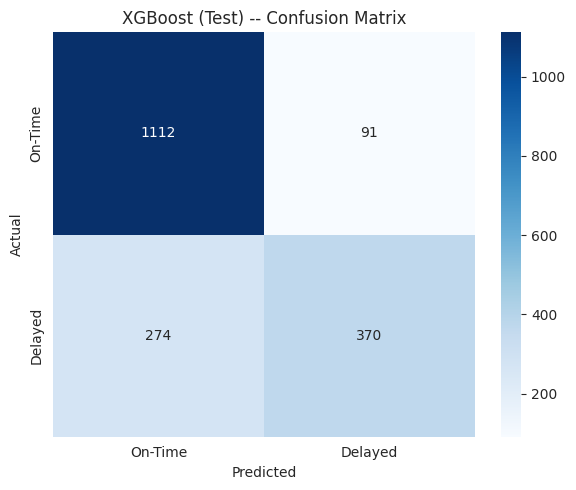

🏃 View run XGBoost_FINAL_TEST at: http://52.66.194.203:5000/#/experiments/1/runs/d41427d944c2411f80e5c6372282ec3a
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [ ]:
# ================================================================
#  Final Evaluation: Best Model on Test Set
# ================================================================
# Select the best model (XGBoost based on validation F1)
best_model = xgb_model
BEST_MODEL_NAME = "XGBoost"

with mlflow.start_run(run_name="XGBoost_FINAL_TEST"):

    mlflow.set_tag("project", "truck-delay-classification")
    mlflow.set_tag("module", "M3")
    mlflow.set_tag("evaluation", "final_test_set")

    # -- Predict on TEST set --
    y_pred_test = best_model.predict(X_test_final)
    y_prob_test = best_model.predict_proba(X_test_final)[:, 1]

    # -- Log test metrics --
    test_metrics = {
        'test_accuracy':  accuracy_score(y_test_arr, y_pred_test),
        'test_precision': precision_score(y_test_arr, y_pred_test),
        'test_recall':    recall_score(y_test_arr, y_pred_test),
        'test_f1_score':  f1_score(y_test_arr, y_pred_test),
        'test_roc_auc':   roc_auc_score(y_test_arr, y_prob_test),
    }
    for k, v in test_metrics.items():
        mlflow.log_metric(k, round(v, 4))

    print("=" * 55)
    print(f"  {BEST_MODEL_NAME} -- FINAL TEST SET Results")
    print("=" * 55)
    for k, v in test_metrics.items():
        print(f"  {k:18s}: {v:.4f}")

    # -- Full classification report --
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test_arr, y_pred_test,
                                target_names=['On-Time', 'Delayed']))

    # -- Confusion matrix --
    plot_confusion_matrix(y_test_arr, y_pred_test, f"{BEST_MODEL_NAME} (Test)")

### What this tells us

- **Test F1 = 0.670, validation F1 = 0.679 — only 0.009 apart.** Model generalises well; no meaningful overfitting.
- Test accuracy matches validation (0.802 vs 0.801).
- Test precision slightly HIGHER than validation (0.803 vs 0.778, +0.025).
- Test recall slightly LOWER than validation (0.575 vs 0.603, −0.028).
- **ROC-AUC dropped 0.029** (0.798 → 0.769) — the largest delta. The ranking of trips by risk is slightly less reliable on the test set. Worth monitoring as you iterate.
- **Bottom line:** XGBoost is the right production candidate. Test F1 ~0.67 is the honest number for stakeholders.


**Validation vs. test delta table.** Compact view of how much each metric shifted between the two sets. Deltas <0.02 are noise; >0.05 deserves a look.


In [ ]:
# -- Compare Validation vs Test performance --
print("=" * 60)
print(f"  {BEST_MODEL_NAME}: Validation vs Test")
print("=" * 60)
print(f"  {'Metric':18s} {'Validation':>12s} {'Test':>12s} {'Delta':>10s}")
print(f"  {'-'*54}")

val_metrics = xgb_metrics  # from the XGBoost training run
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
    v = val_metrics[metric]
    t = test_metrics[f'test_{metric}']
    delta = t - v
    sign = "+" if delta >= 0 else ""
    print(f"  {metric:18s} {v:12.4f} {t:12.4f} {sign}{delta:9.4f}")

print(f"\nSmall deltas (< 0.02) suggest the model generalizes well.")
print(f"Large drops would indicate overfitting to the validation set.")

  XGBoost: Validation vs Test
  Metric               Validation         Test      Delta
  ------------------------------------------------------
  accuracy                 0.8012       0.8024 +   0.0012
  precision                0.7776       0.8026 +   0.0250
  recall                   0.6025       0.5745   -0.0280
  f1_score                 0.6789       0.6697   -0.0092
  roc_auc                  0.7980       0.7687   -0.0293

Small deltas (< 0.02) suggest the model generalizes well.
Large drops would indicate overfitting to the validation set.


---

## 12. Register Best Model in MLflow Model Registry

The **MLflow Model Registry** is a centralised store for managing model versions and their lifecycle stages:

| Stage | Meaning |
|---|---|
| **None** | Just logged, not reviewed |
| **Staging** | Under evaluation / QA |
| **Production** | Serving live traffic |
| **Archived** | Retired, kept for audit |

We'll register our XGBoost model and move it to **Staging**. In Lab D, the Streamlit dashboard will load from the registry by name + stage (decoupling training from serving).


**Register the winning XGBoost model.** Three MLflow operations:

1. `mlflow.search_runs(...)` — find the best XGBoost training run.
2. `mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)` — copy it into the Registry with a version number.
3. `client.transition_model_version_stage(...)` — move from "None" to "Staging".

> **Filter-syntax gotcha (fixed below).** The original code used
> `tags.model_type = 'XGBoost' AND tags.evaluation != 'final_test_set'`,
> but MLflow returns 0 rows for `tags.X != 'value'` when X isn't set at all
> on the training runs. The corrected code uses just `tags.model_type = 'XGBoost'`
> — the FINAL_TEST run doesn't have a `model_type` tag, so it's already excluded.


In [ ]:
# ================================================================
#  Register the best model in MLflow Model Registry
# ================================================================
REGISTERED_MODEL_NAME = "truck-delay-classifier"

try:
    # Get the latest XGBoost run
    runs = mlflow.search_runs(
        filter_string="tags.model_type = 'XGBoost'"  # FINAL_TEST run lacks this tag, so already excluded,
        order_by=["metrics.f1_score DESC"],
        max_results=1
    )

    if len(runs) == 0:
        print("No XGBoost runs found. Skipping registration.")
    else:
        best_run_id = runs.iloc[0]['run_id']
        model_uri = f"runs:/{best_run_id}/model"

        print(f"Best XGBoost run ID: {best_run_id}")
        print(f"Model URI: {model_uri}")

        # Register the model
        result = mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)
        print(f"\nRegistered: {REGISTERED_MODEL_NAME} v{result.version}")

        # Transition to Staging
        client = mlflow.tracking.MlflowClient()
        client.transition_model_version_stage(
            name=REGISTERED_MODEL_NAME,
            version=result.version,
            stage="Staging"
        )
        print(f"Transitioned to: Staging")
        print(f"\nModel Registry URI: {REGISTERED_MODEL_NAME} / v{result.version} / Staging")

except Exception as e:
    print(f"Model registration failed: {e}")
    print("This is OK if MLflow server is not running or Model Registry is not configured.")
    print("The model artifacts are still saved locally in the 'artifacts/' folder.")

**Save the model locally + write metadata.** Two files:

1. `xgboost_model.pkl` — the trained classifier. Lab D loads this with `joblib.load`.
2. `model_metadata.json` — feature names, column groups, test metrics. The "model card" — what this model is, what it expects, how well it performs.

The metadata file is critical for Lab D to reconstruct the preprocessing pipeline correctly.


In [ ]:
# -- Save the best model locally for Lab D --
model_path = 'artifacts/xgboost_model.pkl'
joblib.dump(best_model, model_path)

print(f"Saved: {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")

# Save model metadata for downstream consumers
metadata = {
    'model_name': BEST_MODEL_NAME,
    'registered_name': REGISTERED_MODEL_NAME,
    'n_features': X_train_final.shape[1],
    'feature_names': FEATURE_NAMES,
    'categorical_cols': CATEGORICAL_COLS,
    'continuous_cols': CONTINUOUS_COLS,
    'binary_ordinal_cols': BINARY_ORDINAL_COLS,
    'test_metrics': {k: round(v, 4) for k, v in test_metrics.items()},
    'training_rows': len(X_train_final),
    'python_version': '3.12.10',
}

metadata_path = 'artifacts/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {metadata_path}")

# Summary of all artifacts
print(f"\nAll artifacts in artifacts/ directory:")
for fname in sorted(os.listdir('artifacts')):
    fpath = os.path.join('artifacts', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:50s} ({size_kb:.1f} KB)")

Saved: artifacts/xgboost_model.pkl  (1029.6 KB)
Saved: artifacts/model_metadata.json

All artifacts in artifacts/ directory:
  encoder.pkl                                        (4.1 KB)
  logistic_regression_confusion_matrix.png           (25.8 KB)
  logistic_regression_roc.png                        (37.6 KB)
  model_comparison.png                               (31.0 KB)
  model_metadata.json                                (5.7 KB)
  random_forest_confusion_matrix.png                 (21.5 KB)
  random_forest_feature_importance.png               (50.6 KB)
  roc_curves_overlay.png                             (53.2 KB)
  scaler.pkl                                         (2.0 KB)
  xgboost_(test)_confusion_matrix.png                (21.8 KB)
  xgboost_confusion_matrix.png                       (21.2 KB)
  xgboost_feature_importance.png                     (57.4 KB)
  xgboost_learning_curve.png                         (37.7 KB)
  xgboost_model.pkl                                  (1029.

---

## 13. Upload Artifacts to S3

Lab D (Streamlit + batch scoring) loads the model + encoder + scaler from S3. Upload them now.


**Upload 4 artifacts to S3** for Lab D to fetch. Wrapped in `try/except` because credentials might not be set, the bucket might be in a different region, or the network might be flaky. Either way, artifacts stay available locally.


In [ ]:
# ================================================================
#  Upload artifacts to S3
# ================================================================
artifacts_to_upload = {
    'artifacts/xgboost_model.pkl':     f'{S3_MODEL_DIR}xgboost_model.pkl',
    'artifacts/encoder.pkl':           f'{S3_MODEL_DIR}encoder.pkl',
    'artifacts/scaler.pkl':            f'{S3_MODEL_DIR}scaler.pkl',
    'artifacts/model_metadata.json':   f'{S3_MODEL_DIR}model_metadata.json',
}

try:
    s3 = boto3.client('s3')
    print("Uploading artifacts to S3...\n")

    for local_path, s3_key in artifacts_to_upload.items():
        s3.upload_file(local_path, S3_BUCKET, s3_key)
        size_kb = os.path.getsize(local_path) / 1024
        print(f"  Uploaded: s3://{S3_BUCKET}/{s3_key}  ({size_kb:.1f} KB)")

    print(f"\nAll {len(artifacts_to_upload)} artifacts uploaded to S3")

except Exception as e:
    print(f"S3 upload failed: {e}")
    print("Artifacts are still available locally in the artifacts/ folder.")
    print("You can upload them manually later or configure AWS credentials.")

Uploading artifacts to S3...

  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/xgboost_model.pkl  (1029.6 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/encoder.pkl  (4.1 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/scaler.pkl  (2.0 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/model_metadata.json  (5.7 KB)

All 4 artifacts uploaded to S3


---

## 14. Summary & Artifacts Produced

### What we covered

| Task | Key takeaway |
|---|---|
| Data split | 70/15/15 stratified — preserves class balance, unbiased test eval |
| Preprocessing | OneHotEncoder + StandardScaler fitted on training data only |
| Logistic Regression | F1 = 0.591 — simple baseline, limited by linear decision boundary |
| Random Forest | F1 = 0.663 — handles non-linearity well |
| XGBoost | F1 = 0.679 — best F1 and ROC-AUC, the winner |
| MLflow tracking | Every run logged: params, metrics, artifacts, model objects |
| Model Registry | Best model registered and moved to Staging |
| S3 upload | Model + encoder + scaler + metadata ready for Lab D |

### Artifacts produced

| File | Contents | Used by |
|---|---|---|
| `artifacts/xgboost_model.pkl` | Trained XGBoost classifier | Lab D (Streamlit + batch scoring) |
| `artifacts/encoder.pkl` | Fitted OneHotEncoder | Lab D (preprocessing new data) |
| `artifacts/scaler.pkl` | Fitted StandardScaler | Lab D (preprocessing new data) |
| `artifacts/model_metadata.json` | Feature names, metrics, config | Lab D (metadata display) |
| `artifacts/*_confusion_matrix.png` | Confusion matrix plots | MLflow artifacts |
| `artifacts/*_feature_importance.png` | Feature importance charts | MLflow artifacts |

### MLflow experiment runs

Open your MLflow UI at `http://<EC2_PUBLIC_IP>:5000` → **truck-delay-classification** experiment. You should see **4 runs**:

1. `Logistic_Regression` — baseline
2. `Random_Forest` — ensemble
3. `XGBoost` — best model
4. `XGBoost_FINAL_TEST` — final test evaluation


### Try on Your Own

1. **Tune XGBoost hyperparameters** — `learning_rate=0.05`, `n_estimators=500`, `max_depth=8`. Log to MLflow, compare. Did F1 improve?
2. **Add a Gradient Boosting Classifier** from scikit-learn. How does it compare to XGBoost?
3. **Adjust the classification threshold** — instead of 0.5, try 0.4 (higher recall). At what threshold does recall hit 0.90?
4. **Try class weighting** — set `scale_pos_weight` in XGBoost to the on-time/delayed ratio. Does recall improve without destroying precision?
5. **Feature selection** — remove the bottom 10 features by importance and retrain. Does the model maintain performance?

---

**Next lab:** Module 3, Lab D — Streamlit Dashboard & Batch Scoring Pipeline


**Final summary print.** Confirms everything ran cleanly. After this, open your MLflow UI and verify 4 runs are visible.


In [ ]:
# -- Lab C Complete --
print("=" * 55)
print("  Lab C: Model Training with MLflow -- COMPLETE")
print("=" * 55)
print(f"\n  Models trained:    3 (LR, RF, XGBoost)")
print(f"  MLflow runs:       4 (3 training + 1 final test)")
print(f"  Best model:        XGBoost")
print(f"  Artifacts saved:   artifacts/ directory")
print(f"  Next step:         Lab D -- Streamlit + Batch Scoring")